In [1]:
# Cell 1 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.family"] = "sans-serif"
sns.set_theme(style="darkgrid", palette="muted")

os.makedirs("../outputs", exist_ok=True)

print("All libraries loaded successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")


# Press **Shift+Enter** to run it — you should see:
# ```
# All libraries loaded successfully!
# pandas version: 2.x.x
# numpy version: 1.x.x

All libraries loaded successfully!
pandas version: 2.3.3
numpy version: 2.4.3


In [2]:
# Cell 2 — Load all datasets
races             = pd.read_csv("../data/races.csv")
drivers           = pd.read_csv("../data/drivers.csv")
results           = pd.read_csv("../data/results.csv")
constructors      = pd.read_csv("../data/constructors.csv")
driver_standings  = pd.read_csv("../data/driver_standings.csv")
constructor_standings = pd.read_csv("../data/constructor_standings.csv")
qualifying        = pd.read_csv("../data/qualifying.csv")
circuits          = pd.read_csv("../data/circuits.csv")
pit_stops         = pd.read_csv("../data/pit_stops.csv")
sprint_results    = pd.read_csv("../data/sprint_results.csv")

print("All datasets loaded!")
print(f"Races:                {races.shape}")
print(f"Drivers:              {drivers.shape}")
print(f"Results:              {results.shape}")
print(f"Constructors:         {constructors.shape}")
print(f"Driver standings:     {driver_standings.shape}")
print(f"Constructor standing: {constructor_standings.shape}")
print(f"Qualifying:           {qualifying.shape}")
print(f"Circuits:             {circuits.shape}")
print(f"Pit stops:            {pit_stops.shape}")
print(f"Sprint results:       {sprint_results.shape}")

All datasets loaded!
Races:                (1125, 18)
Drivers:              (861, 9)
Results:              (26759, 18)
Constructors:         (212, 5)
Driver standings:     (34863, 7)
Constructor standing: (13391, 7)
Qualifying:           (10494, 9)
Circuits:             (77, 9)
Pit stops:            (11371, 7)
Sprint results:       (360, 16)


In [5]:
# Cell 3 — Clean data and filter to 2020-2024
# Fix \N missing values (common in this dataset)
results.replace("\\N", np.nan, inplace=True)
qualifying.replace("\\N", np.nan, inplace=True)
driver_standings.replace("\\N", np.nan, inplace=True)
constructor_standings.replace("\\N", np.nan, inplace=True)
sprint_results.replace("\\N", np.nan, inplace=True)

# Convert columns to correct types
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors="coerce")
results["points"]        = pd.to_numeric(results["points"], errors="coerce")
results["grid"]          = pd.to_numeric(results["grid"], errors="coerce")
results["laps"]          = pd.to_numeric(results["laps"], errors="coerce")

# Filter races to 2020-2024 only
modern_races = races[races["year"].between(2020, 2024)].copy()

# Get raceIds for 2020-2024
modern_raceIds = modern_races["raceId"].tolist()

# Filter all other datasets to match
modern_results   = results[results["raceId"].isin(modern_raceIds)].copy()
modern_quali     = qualifying[qualifying["raceId"].isin(modern_raceIds)].copy()
modern_pitstops  = pit_stops[pit_stops["raceId"].isin(modern_raceIds)].copy()
modern_dstandings = driver_standings[driver_standings["raceId"].isin(modern_raceIds)].copy()

print(f"Modern era races (2020-2024): {len(modern_races)}")
print(f"Modern era results:           {len(modern_results)}")
print(f"Modern era qualifying:        {len(modern_quali)}")
print(f"Modern era pit stops:         {len(modern_pitstops)}")
print(f"\nYears covered: {sorted(modern_races['year'].unique())}")
print(f"Total drivers in this era:    {modern_results['driverId'].nunique()}")
print(f"Total circuits in this era:   {modern_races['circuitId'].nunique()}")

Modern era races (2020-2024): 107
Modern era results:           2139
Modern era qualifying:        2138
Modern era pit stops:         3934

Years covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Total drivers in this era:    36
Total circuits in this era:   30


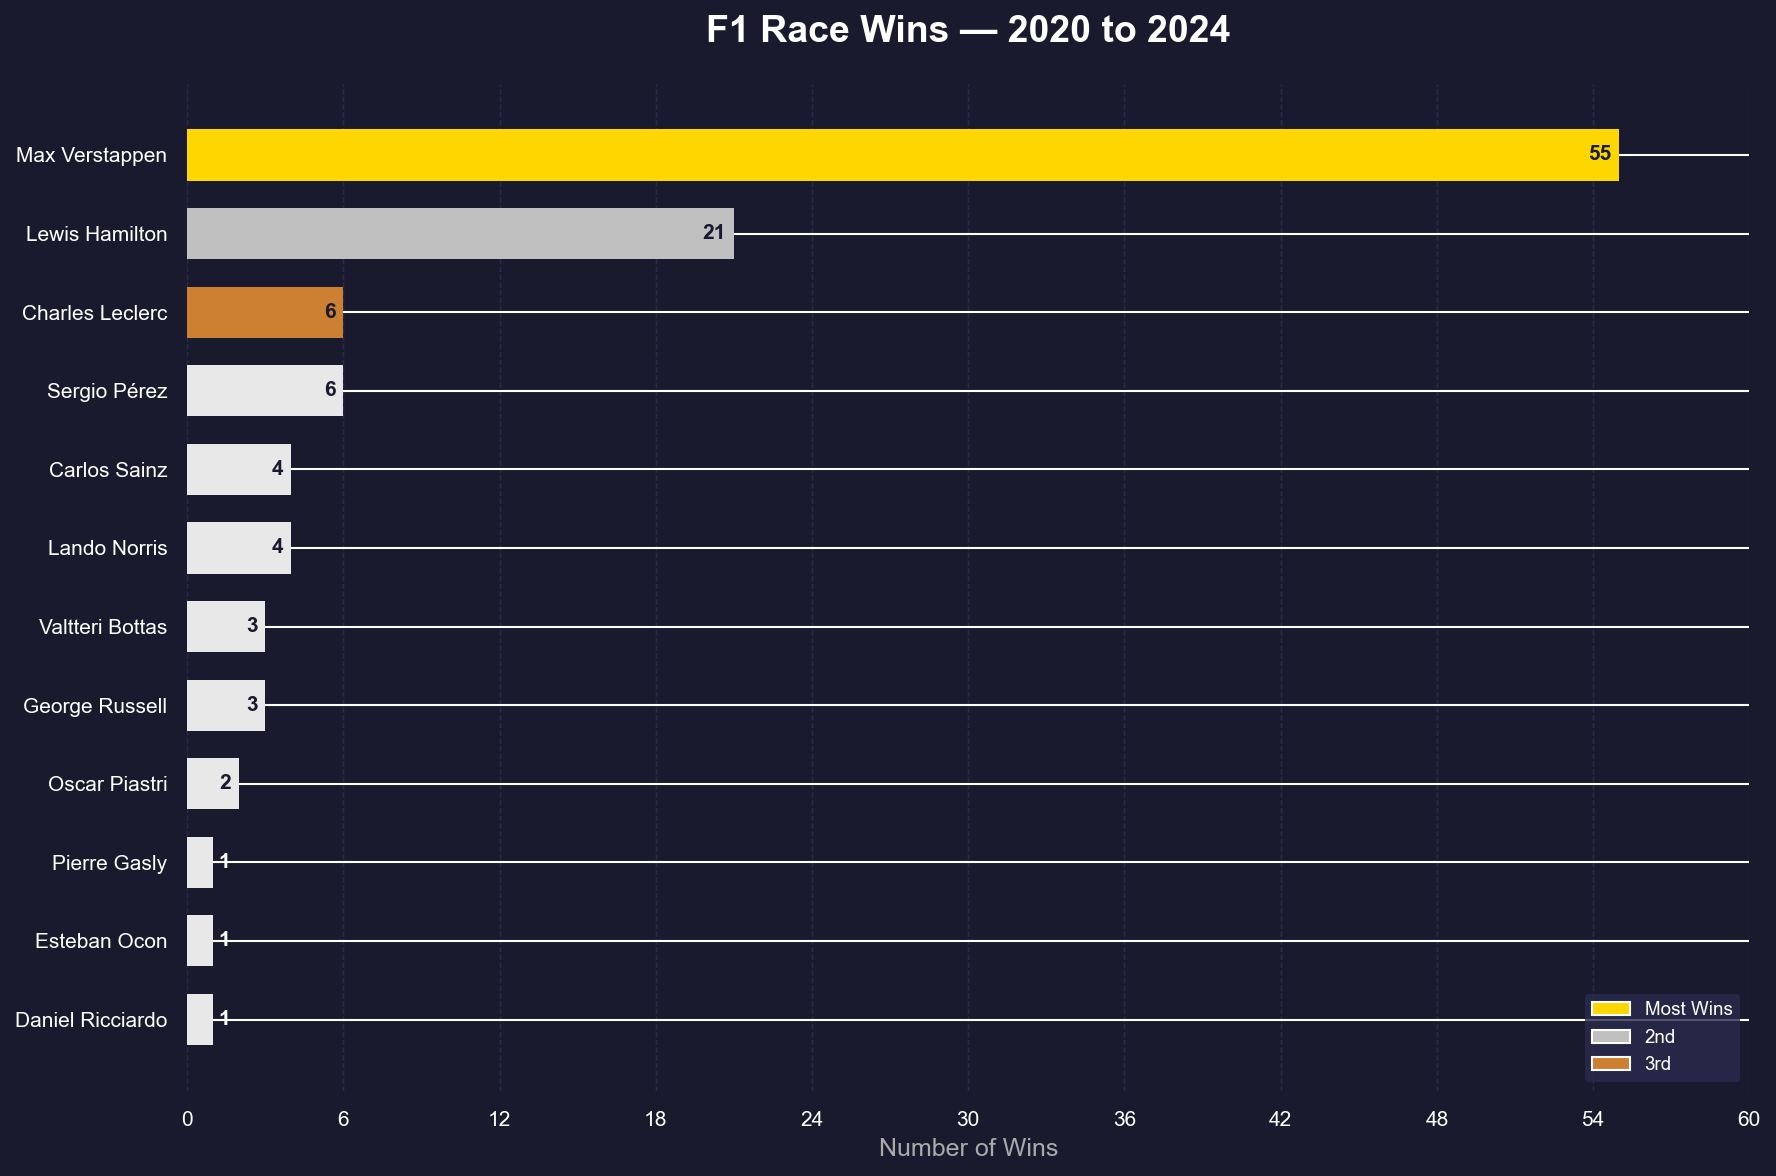

✅ Cell 4 complete — Driver Wins chart saved.


In [7]:
# ============================================================
# CELL 4 — DRIVER WINS 2020-2024
# ============================================================

import matplotlib.ticker as ticker
from matplotlib.patches import Patch

# Filter for race wins (positionOrder == 1) in 2020-2024
# Note: using positionOrder (numeric) not position (has \N values)
wins_df = modern_results[modern_results['positionOrder'] == 1].copy()

# Merge with drivers to get full names
wins_df = wins_df.merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')
wins_df['driver_name'] = wins_df['forename'] + ' ' + wins_df['surname']

# Count wins per driver
win_counts = wins_df['driver_name'].value_counts().reset_index()
win_counts.columns = ['driver_name', 'wins']
win_counts = win_counts.sort_values('wins', ascending=True)  # ascending for horizontal bar

# --- Colour map: highlight top 3 ---
colors = ['#e8e8e8'] * len(win_counts)
top3_positions = list(range(len(win_counts)))[-3:]
palette = ['#CD7F32', '#C0C0C0', '#FFD700']  # bronze, silver, gold
for rank, pos in enumerate(top3_positions):
    colors[pos] = palette[rank]

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(win_counts['driver_name'], win_counts['wins'],
               color=colors, edgecolor='none', height=0.65)

# Add value labels inside bars
for bar, val in zip(bars, win_counts['wins']):
    label_x = bar.get_width() - 0.3 if bar.get_width() > 1 else bar.get_width() + 0.2
    ha = 'right' if bar.get_width() > 1 else 'left'
    ax.text(label_x, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va='center', ha=ha, fontsize=10,
            fontweight='bold', color='#1a1a2e' if bar.get_width() > 1 else 'white')

# Styling
ax.set_title('F1 Race Wins — 2020 to 2024', fontsize=18, fontweight='bold',
             color='white', pad=20)
ax.set_xlabel('Number of Wins', fontsize=12, color='#aaaaaa')
ax.tick_params(colors='white', labelsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', color='#333355', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_xlim(0, win_counts['wins'].max() + 5)

# Legend
legend_elements = [Patch(facecolor='#FFD700', label='Most Wins'),
                   Patch(facecolor='#C0C0C0', label='2nd'),
                   Patch(facecolor='#CD7F32', label='3rd')]
ax.legend(handles=legend_elements, loc='lower right',
          facecolor='#2a2a4e', edgecolor='none', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('driver_wins_2020_2024.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 4 complete — Driver Wins chart saved.")

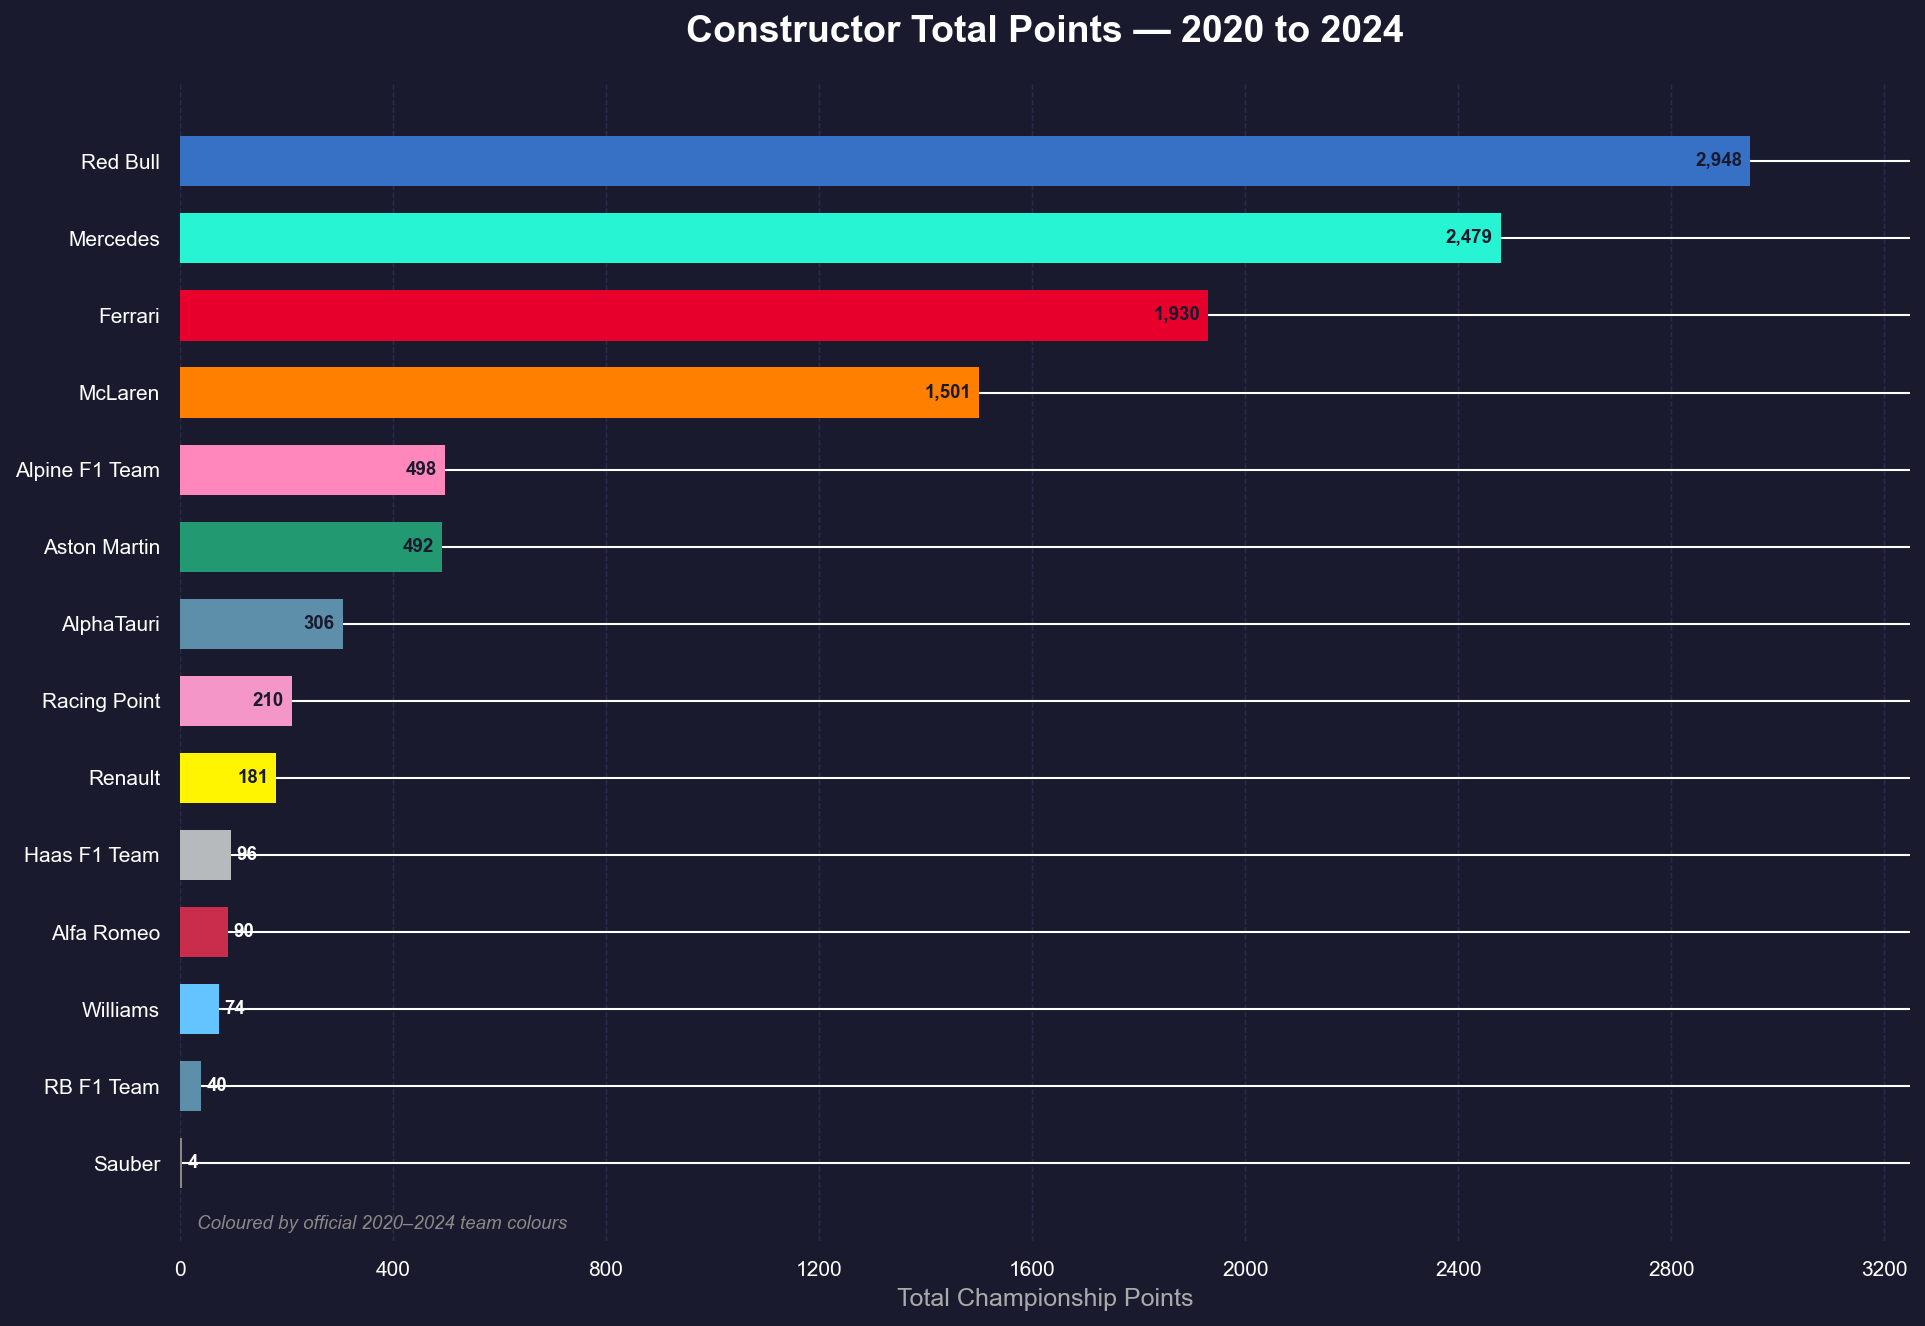

✅ Cell 5 complete — Constructor Points chart saved.


In [8]:
# ============================================================
# CELL 5 — CONSTRUCTOR CHAMPIONSHIP POINTS 2020-2024
# ============================================================

# Merge modern_results with constructors to get team names
constructor_pts = modern_results.merge(
    constructors[['constructorId', 'name']], on='constructorId', how='left'
)

# Sum total points per constructor across 2020-2024
constructor_totals = constructor_pts.groupby('name')['points'].sum().reset_index()
constructor_totals.columns = ['constructor', 'total_points']
constructor_totals = constructor_totals.sort_values('total_points', ascending=True)

# --- F1 team colours (2020-2024 grid) ---
team_colors = {
    'Red Bull':          '#3671C6',
    'Mercedes':          '#27F4D2',
    'Ferrari':           '#E8002D',
    'McLaren':           '#FF8000',
    'Aston Martin':      '#229971',
    'Alpine F1 Team':    '#FF87BC',
    'Williams':          '#64C4FF',
    'AlphaTauri':        '#5E8FAA',
    'RB F1 Team':        '#5E8FAA',
    'Alfa Romeo':        '#C92D4B',
    'Haas F1 Team':      '#B6BABD',
    'Racing Point':      '#F596C8',
    'Renault':           '#FFF500',
    'Toro Rosso':        '#5E8FAA',
    'Alfa Romeo Racing': '#C92D4B',
}

# Assign colours — fallback to grey if team not in dict
bar_colors = [
    team_colors.get(team, '#888888')
    for team in constructor_totals['constructor']
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 9))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

bars = ax.barh(
    constructor_totals['constructor'],
    constructor_totals['total_points'],
    color=bar_colors, edgecolor='none', height=0.65
)

# Value labels
for bar, val in zip(bars, constructor_totals['total_points']):
    label_x = bar.get_width() - 15 if bar.get_width() > 100 else bar.get_width() + 10
    ha       = 'right' if bar.get_width() > 100 else 'left'
    ax.text(label_x, bar.get_y() + bar.get_height() / 2,
            f'{int(val):,}', va='center', ha=ha, fontsize=9,
            fontweight='bold',
            color='#1a1a2e' if bar.get_width() > 100 else 'white')

# Styling
ax.set_title('Constructor Total Points — 2020 to 2024', fontsize=18,
             fontweight='bold', color='white', pad=20)
ax.set_xlabel('Total Championship Points', fontsize=12, color='#aaaaaa')
ax.tick_params(colors='white', labelsize=10)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.grid(axis='x', color='#333355', linestyle='--', linewidth=0.7, alpha=0.7)
ax.set_xlim(0, constructor_totals['total_points'].max() + 300)

# Subtitle annotation
ax.annotate('Coloured by official 2020–2024 team colours',
            xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=9, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('constructor_points_2020_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 5 complete — Constructor Points chart saved.")

Top 5 drivers (2023-2024): ['Max Verstappen', 'Lando Norris', 'Charles Leclerc', 'Carlos Sainz', 'Lewis Hamilton']


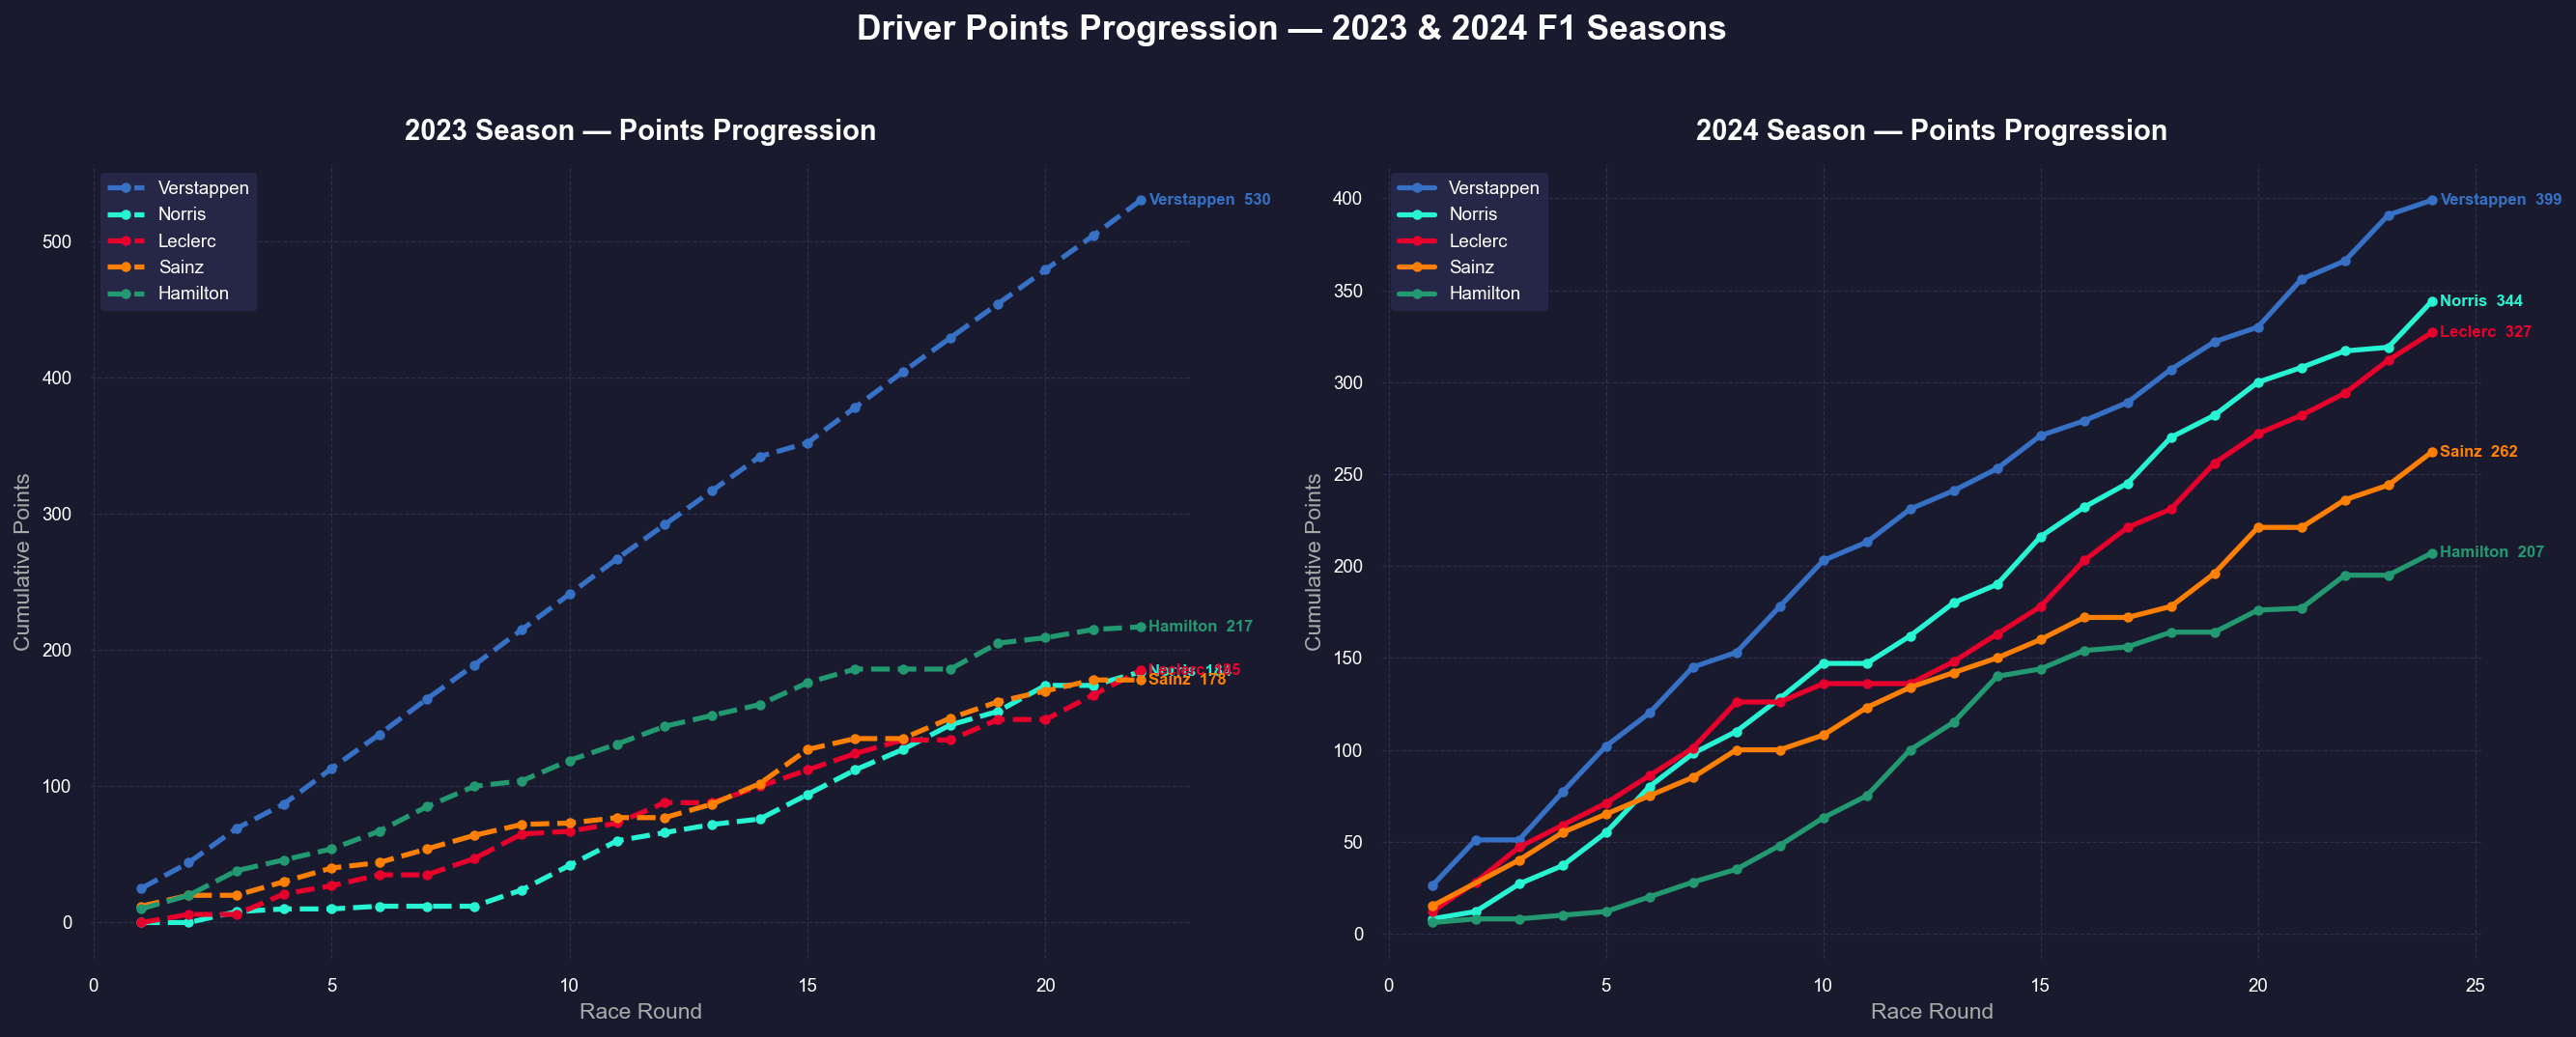

✅ Cell 6 complete — Points Progression chart saved.


In [9]:
# ============================================================
# CELL 6 — POINTS PROGRESSION 2023 & 2024 (TOP 5 DRIVERS)
# ============================================================

# Filter to 2023 and 2024 only
races_2324 = modern_races[modern_races['year'].isin([2023, 2024])].copy()
results_2324 = modern_results[modern_results['raceId'].isin(races_2324['raceId'])].copy()

# Merge results with race info to get round number + year
results_2324 = results_2324.merge(
    races_2324[['raceId', 'year', 'round', 'name']], on='raceId', how='left'
)

# Merge with drivers for names
results_2324 = results_2324.merge(
    drivers[['driverId', 'forename', 'surname']], on='driverId', how='left'
)
results_2324['driver_name'] = results_2324['forename'] + ' ' + results_2324['surname']

# Sort by year and round so cumsum is correct
results_2324 = results_2324.sort_values(['driver_name', 'year', 'round'])

# Cumulative points per driver per year
results_2324['cumulative_points'] = results_2324.groupby(
    ['driver_name', 'year']
)['points'].cumsum()

# --- Find top 5 drivers by total points across 2023+2024 ---
top5_drivers = (
    results_2324.groupby('driver_name')['points']
    .sum()
    .nlargest(5)
    .index.tolist()
)
print(f"Top 5 drivers (2023-2024): {top5_drivers}")

# Filter to top 5 only
plot_df = results_2324[results_2324['driver_name'].isin(top5_drivers)]

# --- Driver colours ---
driver_colors = {
    top5_drivers[0]: '#3671C6',   # Blue   — likely Verstappen
    top5_drivers[1]: '#27F4D2',   # Teal   — likely Hamilton/Russell
    top5_drivers[2]: '#E8002D',   # Red    — likely Leclerc/Sainz
    top5_drivers[3]: '#FF8000',   # Orange — likely Norris
    top5_drivers[4]: '#229971',   # Green  — likely Alonso
}

# --- Line styles per year ---
line_styles = {2023: '--', 2024: '-'}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)
fig.patch.set_facecolor('#1a1a2e')

for ax, year in zip(axes, [2023, 2024]):
    ax.set_facecolor('#1a1a2e')
    year_df = plot_df[plot_df['year'] == year]

    for driver in top5_drivers:
        d_df = year_df[year_df['driver_name'] == driver].sort_values('round')
        if d_df.empty:
            continue
        ax.plot(
            d_df['round'],
            d_df['cumulative_points'],
            color=driver_colors[driver],
            linewidth=2.5,
            linestyle=line_styles[year],
            marker='o', markersize=4,
            label=driver.split()[-1]   # surname only for clean legend
        )
        # End-of-season label
        last = d_df.iloc[-1]
        ax.annotate(
            f"{driver.split()[-1]}  {int(last['cumulative_points'])}",
            xy=(last['round'], last['cumulative_points']),
            xytext=(4, 0), textcoords='offset points',
            fontsize=8, color=driver_colors[driver],
            va='center', fontweight='bold'
        )

    # Styling per subplot
    ax.set_title(f'{year} Season — Points Progression',
                 fontsize=14, fontweight='bold', color='white', pad=12)
    ax.set_xlabel('Race Round', fontsize=11, color='#aaaaaa')
    ax.set_ylabel('Cumulative Points', fontsize=11, color='#aaaaaa')
    ax.tick_params(colors='white', labelsize=9)
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.grid(color='#333355', linestyle='--', linewidth=0.6, alpha=0.8)
    ax.legend(facecolor='#2a2a4e', edgecolor='none',
              labelcolor='white', fontsize=9, loc='upper left')

fig.suptitle('Driver Points Progression — 2023 & 2024 F1 Seasons',
             fontsize=17, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('points_progression_2023_2024.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 6 complete — Points Progression chart saved.")